In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

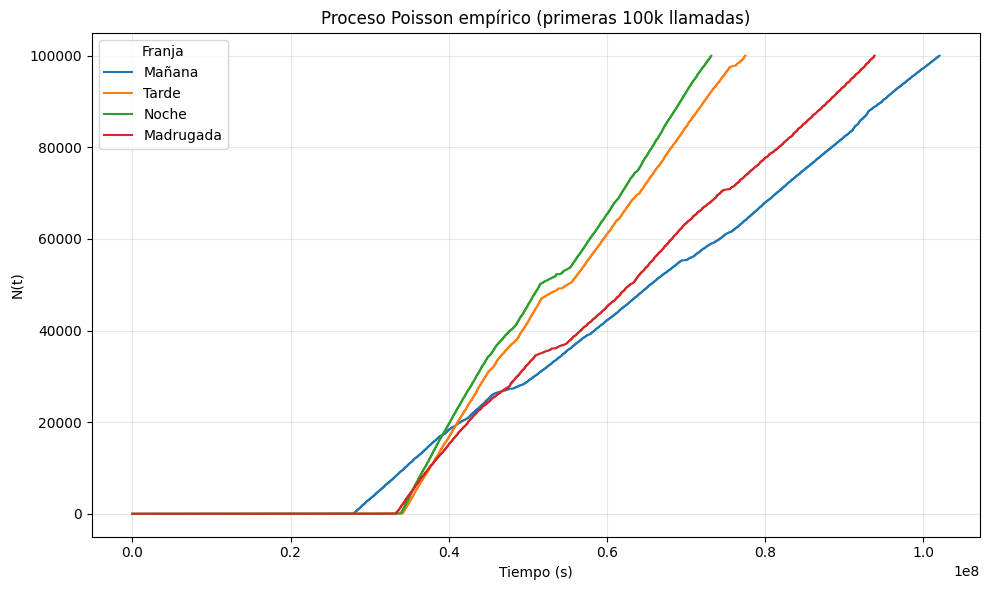

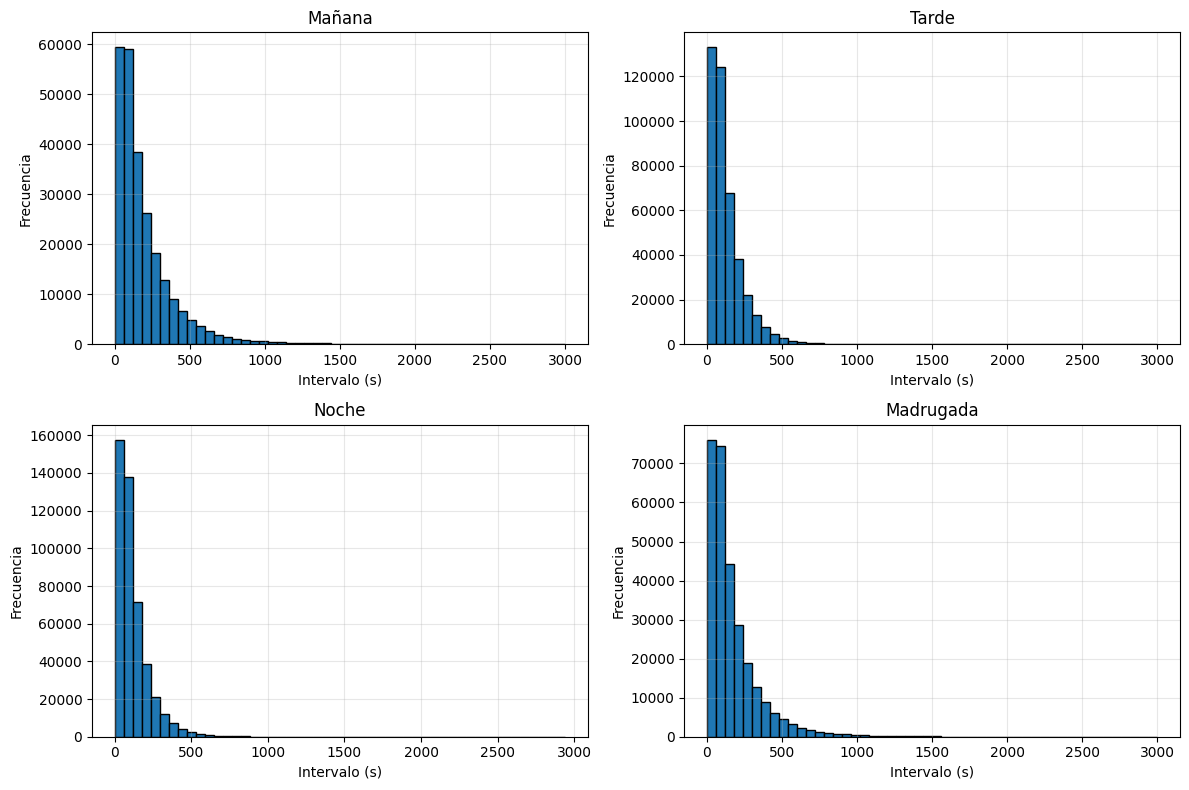

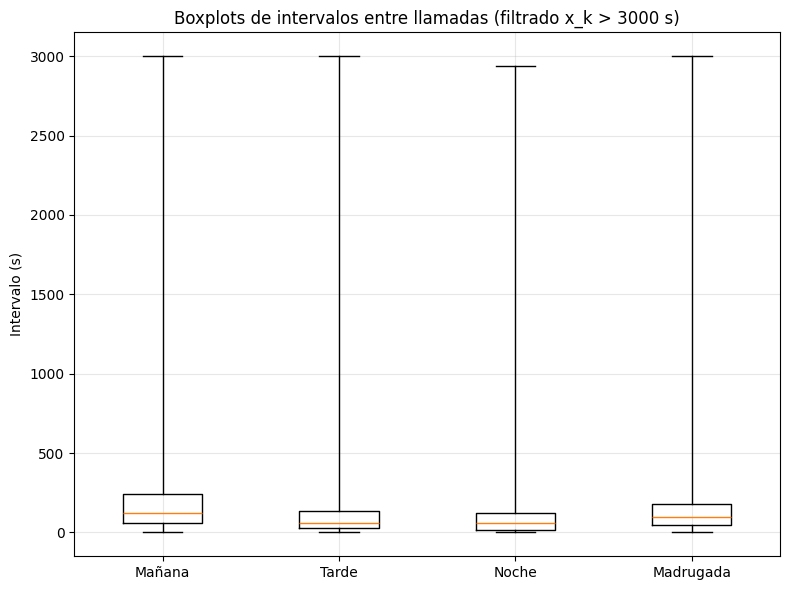

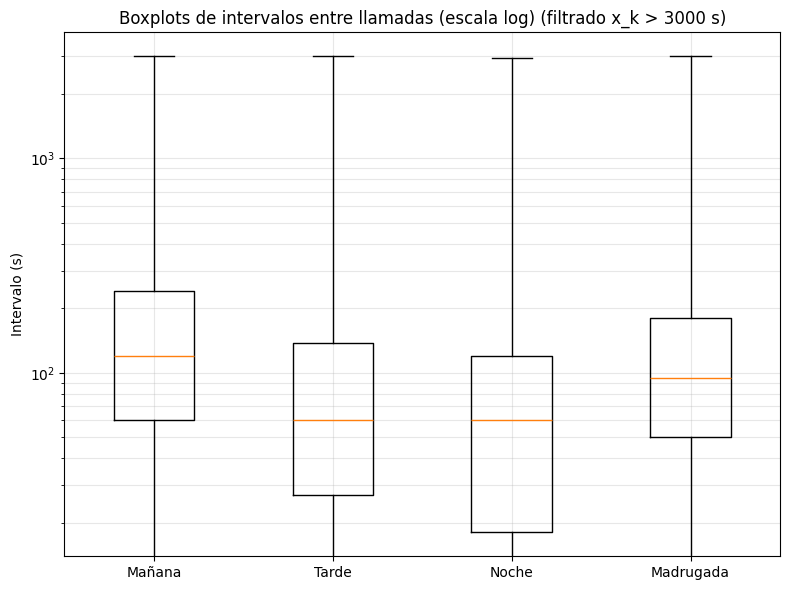

In [3]:
# BEGIN: Adjusting figure sizes for smaller graphs
def main():
    df = pd.read_csv('911_times.csv')
    
    # 2. Proceso Poisson (parte a)
    n = min(100_000, len(df))
    plt.figure(figsize=(10, 6))
    for col in ['mañana', 'tarde', 'noche', 'madrugada']:
        times = df[col].iloc[:n].values
        counts = np.arange(1, len(times) + 1)
        plt.step(times, counts, where='post', label=col.capitalize())
    plt.xlabel('Tiempo (s)')
    plt.ylabel('N(t)')
    plt.title('Proceso Poisson empírico (primeras 100k llamadas)')
    plt.legend(title='Franja')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. Tiempos entre llamadas y filtrado de outliers (parte b)
    diffs = {}
    for col in ['mañana', 'tarde', 'noche', 'madrugada']:
        times = df[col].dropna().values
        x = np.diff(times)
        diffs[col] = x[x <= 3000]
    
    # 4a. Histogramas
    plt.figure(figsize=(12, 8))
    for i, (col, x) in enumerate(diffs.items(), 1):
        plt.subplot(2, 2, i)
        plt.hist(x, bins=50, edgecolor='black')
        plt.title(col.capitalize())
        plt.xlabel('Intervalo (s)')
        plt.ylabel('Frecuencia')
        plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 4b. Boxplots comparativos
    plt.figure(figsize=(8, 6))
    data = [diffs[col] for col in ['mañana', 'tarde', 'noche', 'madrugada']]
    labels = ['Mañana', 'Tarde', 'Noche', 'Madrugada']
    plt.boxplot(data, tick_labels=labels, whis=(0, 100), showfliers=False)
    plt.title('Boxplots de intervalos entre llamadas (filtrado x_k > 3000 s)')
    plt.ylabel('Intervalo (s)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Versión con escala logarítmica para mejor visualización
    plt.figure(figsize=(8, 6))
    data = [diffs[col] for col in ['mañana', 'tarde', 'noche', 'madrugada']]
    labels = ['Mañana', 'Tarde', 'Noche', 'Madrugada']
    plt.boxplot(data, tick_labels=labels, whis=(0, 100), showfliers=False)
    plt.yscale('log')
    plt.title('Boxplots de intervalos entre llamadas (escala log) (filtrado x_k > 3000 s)')
    plt.ylabel('Intervalo (s)')
    plt.grid(alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
    
if __name__ == '__main__':
    main()

In [5]:
#!/usr/bin/env python3
# Ej2.py
# Ejercicio 2: Estimación de tasas λ
# Carga datos de 911_times.csv y calcula:
#  a) Estimador de Máxima Verosimilitud (MLE) para λ
#  b) Estimador Bayesiano (media posterior) con prior Gamma(α=1, β=1)
# Reporta los resultados en tabla impresa por consola.

def main():
    # Parámetros de la prior Gamma
    alpha, beta = 1.0, 1.0

    df = pd.read_csv('911_times.csv')
    franjas = ['mañana', 'tarde', 'noche', 'madrugada']
    results = []

    for franja in franjas:
        # Extraer tiempos y calcular intervalos
        times = df[franja].dropna().values
        x = np.diff(times)
        n = len(x)
        sum_x = int(x.sum())

        # MLE: n / Σx
        lambda_mle = n / sum_x

        # Bayesiano (media de la posterior Gamma(α+n, β+Σx))
        lambda_bayes = (alpha + n) / (beta + sum_x)

        results.append({
            'Franja': franja.capitalize(),
            'n (intervalos)': n,
            'Σ x_i (s)': sum_x,
            'λ_MLE (1/s)': lambda_mle,
            'λ_Bayes (media posterior)': lambda_bayes
        })

    # Presentar resultados: Σ x_i como entero, lambdas con 9 decimales
    df_res = pd.DataFrame(results)
    print("\\nEstimaciones de λ por franja:\\n")
    print(
        df_res.to_string(
            index=False,
            float_format='%.9f' # Ajustado a 9 decimales para que se vea bien la diferencia
        )
    )

if __name__ == '__main__':
    main()

\nEstimaciones de λ por franja:\n
   Franja  n (intervalos)  Σ x_i (s)  λ_MLE (1/s)  λ_Bayes (media posterior)
   Mañana          252683  252563041  0.001000475                0.001000479
    Tarde          420254  258687684  0.001624561                0.001624565
    Noche          459350  258519941  0.001776846                0.001776849
Madrugada          289978  257920893  0.001124290                0.001124294
